### TEST & DEBUG (WITHOUT AI)

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

In [18]:
# 1. Generate Synthetic Data
np.random.seed(42)
num_samples = 500
distance = np.random.uniform(1, 15, num_samples)  # Feature 1
order_value = np.random.uniform(100, 1000, num_samples)  # Feature 2
prep_time = np.random.uniform(10, 60, num_samples)  # Feature 3

X = np.column_stack([distance, order_value, prep_time])

In [19]:
# Define target priority rule (0 = Low, 1 = Medium, 2 = High)
score = (distance * 0.4) + (prep_time * 0.4) + (order_value * 0.002)
y_raw = np.zeros(num_samples, dtype=int)
y_raw[score > np.percentile(score, 33)] = 1
y_raw[score > np.percentile(score, 66)] = 2

# One-hot encode targets for multi-class classification
y = to_categorical(y_raw, num_classes=3)

In [20]:
# Scale inputs for stable network training
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
# 2. Build Model
model = Sequential([
    Dense(16, activation="relu", input_shape=(3,)),
    Dense(8, activation="relu"),
    Dense(3, activation="softmax"),  # FIX 1: Softmax activation for 3-class probability distribution
])

C:\Users\patel prit\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
# 3. Compile Model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",  # FIX 2: Categorical crossentropy for multi-class problem
    metrics=["accuracy"],
)

In [23]:
# 4. Train Model with Validation Split
# FIX 3: Added validation_split=0.2 to calculate val_loss during training
history = model.fit(X_scaled, y, epochs=20, validation_split=0.2, verbose=1)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4650 - loss: 0.9967 - val_accuracy: 0.4400 - val_loss: 0.9722
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4675 - loss: 0.9590 - val_accuracy: 0.4200 - val_loss: 0.9396
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4725 - loss: 0.9225 - val_accuracy: 0.4500 - val_loss: 0.9051
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5075 - loss: 0.8865 - val_accuracy: 0.4700 - val_loss: 0.8698
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5550 - loss: 0.8499 - val_accuracy: 0.5700 - val_loss: 0.8321
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6475 - loss: 0.8118 - val_accuracy: 0.6700 - val_loss: 0.7957
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7150 - loss: 0.7742 - val_accuracy: 0.7200 - val_loss: 0.7591
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7450 - loss: 0.7334 - val_accuracy: 0.7500 - val_loss

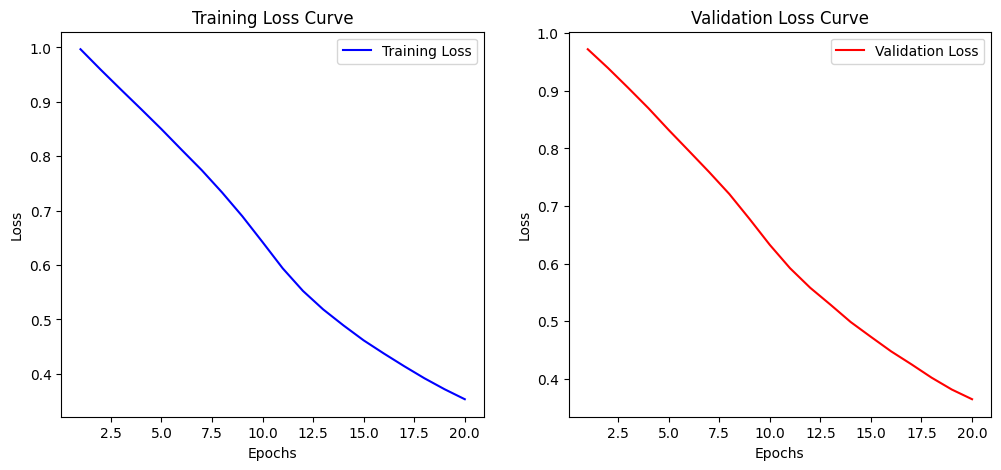

In [ ]:
# 5. Plot Training and Validation Loss Curves Side-by-Side
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, 21), history.history["loss"], label="Training Loss", color="b")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, 21), history.history["val_loss"], label="Validation Loss", color="r")  # FIX 4: val_loss now exists
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Validation Loss Curve")
plt.legend()

plt.show()

In [25]:
# 6. Save and Reload Model for Test Prediction
model.save("food_priority_model.keras")
reloaded_model = tf.keras.models.load_model("food_priority_model.keras")

In [ ]:
# Single Test Prediction (Sample input: 8km, ₹500, 25min prep)
sample_raw = np.array([[8.0, 500.0, 25.0]])
sample_scaled = scaler.transform(sample_raw)

In [30]:
probs = reloaded_model.predict(sample_scaled)[0]
classes = ["Low", "Medium", "High"]
pred_class = classes[np.argmax(probs)]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


In [31]:
print(f"Prediction Output:")
print(f"Predicted Class: {pred_class} | Confidence: {np.max(probs)*100:.1f}%")

Prediction Output:
Predicted Class: High | Confidence: 95.3%


### Explanation of Corrections Made (3–4 Lines)
* The AI's original code used sigmoid activation instead of softmax on the 3-neuron output layer and compiled the model with mean_squared_error rather than categorical_crossentropy, which is improper for multi-class classification. Furthermore, it failed to one-hot encode target labels and omitted the validation_split=0.2 parameter in model.fit(), causing a runtime crash when trying to plot val_loss. I fixed the output activation, loss function, label encoding, and validation split to ensure proper training and side-by-side loss curve plotting.